In [9]:
#Base Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Stats Libraries
from scipy.optimize import minimize
from scipy.stats import norm # cdf, pdf
from scipy.optimize import minimize # Maximum Likelihood
from scipy import stats # t / z test

In [6]:
# what is the probablity of getting marks between 60 and 70 given mean of the class is 43 with std 5
# what is the probablity of getting marks between more than 70 given mean of the class is 60 with std 5

x = 60
mean = 60
std = 5
print(norm.pdf(70,mean,std))  ##Likelihood

print(norm.cdf(70,mean,std) - norm.cdf(60, mean , std))  ##probability PDF  (Q1)

print((1 - norm.cdf(70 , mean , std))) #Q2

z_calc = ((70 - mean) / std)
print(1 - norm.cdf(z_calc)) #Q2 using z_calc value which is used to standerize
#any method can be used to caluate ans in Q2

# norm.cdf/pdf(X,mu,sigma)
# X = Value to find
# mu = mean
# sigma = standart deviation

0.010798193302637612
0.4772498680518208
0.02275013194817921
0.02275013194817921


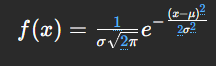

In [7]:
# Used to find parameters in this case mean and standard deviation
# Finds the likelihood to get the data for each random mean and sigma
# here we take -llh because we are minimizing 

from scipy.stats import norm
from scipy.optimize import minimize
data=np.array([1, 2, 3]) # Input data
def negtive_llh(parms,data):
    mu,sigma=parms
    log_prob = norm.logpdf(data, mu, sigma)
    llh=-np.sum(log_prob)
    return llh
#parms=[mu,sigma]
#print(negtive_llh(parms,data))
# Initial guess
initial_guess = [2, 1]
result = minimize(negtive_llh,  # Fuction
                  initial_guess, # Starting Guess
                  args=(data,),  # Input data
                  bounds=[(None, None), (1e-5, None)] # Constarints i.e mean can be anything but sigma should more that 0
                 )
#method='L-BFGS-B'
print(result.x[0])
print(result.x[1])

1.999999994001933
0.8164965400382597


Q. A training program claims that the average completion time is 520 hours.

A random sample of 64 participants shows:
Sample mean = 500 hours

Population standard deviation σ = 80 hours

Test the claim at α=0.05.

In [18]:
# This is a 2 tailed with one sample as more than or less than isnt given, and there is only 1 sample

#Hypothesis:
# H0: mu = 520
# H1: mu /= 520

# Defining variables:

xbar = 500 # Sample mean
mu = 520 # Population Mean

n = 64 # Sample Size
std = 80 #standard deviation

alpha = 0.05 # 1 - significance(not in %)

# z_calc:
se = (std / np.sqrt(n)) # using se as sample is being compared to population
z_calc = ((xbar - mu) / se) # standartization
print(f"z value: {z_calc}")

# Finding rande z_neg, z_pos:
z_pos = stats.norm.ppf(1 - alpha/2)
z_neg = stats.norm.ppf(alpha/2)

# plotting
print(f"{z_neg} ------- {z_calc} ------- {z_pos}") # Here -2 < z_neg. Hence reject H0

# using standard z_neg and z_pos values:
print(f"{(z_neg * se) + mu} ------- {xbar} ------- {(z_pos * se) + mu}") # Here -2 < z_neg. Hence reject H0
# This help us conclude that any value which isnt between 500.4 and 539.6 will be rejected similarly i.e if sample mean was 540 it would be rejected too

z value: -2.0
-1.9599639845400545 ------- -2.0 ------- 1.959963984540054
500.40036015459947 ------- 500 ------- 539.5996398454006


Q. Steve Cutter sells Big Blade lawn mowers in his hardware store, and he isinterested 
in comparing the reliability of the mowers he sells with the reliabilityof Big Blade 
mowers sold nationwide. Steve knows that only 15 percent of all Big Blade mowers sold 
nationwide require repairs during the first year of ownership. 
A sample of 120 of Steve’s customers revealed that exactly 22 of 
them required mower repairs in the first year of ownership. At the 0.02 level of 
significance, is there evidence that Steve’s Big Blade mowers differ inreliability 
from those sold nationwide?

In [20]:
##The null hypothesis is that p = 0.15. We begin with computing the test statistic.
#H0:p = 0.15
#Ha:p =/= 0.15
import numpy as np
from scipy import stats
pbar = 22/120          # sample proportion 
p = 0.15                # hypothesized value 
n = 120                # sample size 

se = np.sqrt((p*(1-p))/n)
Z_cal = (pbar-p)/se
print(Z_cal) 

##two side 2%
alpha=0.02/2
stats.norm.ppf(1-alpha)
z_table_positive=(stats.norm.ppf(1-alpha))
z_table_negative=(stats.norm.ppf(alpha))
print()
print(z_table_positive, "    ",z_table_negative)  ##Accept Ho
print()

#0r
print(stats.norm.cdf(Z_cal))  
## p value >0.05 that's why Accept Ho
#0r
print()
print(p-z_table_positive*se,'      ',p+z_table_positive*se)

#pbar is inbetween the range that's why we accept the hypothesis

1.022619985129827

2.3263478740408408      -2.3263478740408408

0.8467562216924602

0.0741703367210744        0.2258296632789256


Q.Two independent samples of observations were collected. For the first sample of 60 
elements, the mean was 86 and the standard deviation 6. The second sample of 75 elements 
had a mean of 82 and a standard deviation of 9.
(a) Compute the estimated standard error of the difference between the two means.
(b) Using alpha = 0.01, test whether the two sample can reasonably be considered to have come from populations with the same mean.

In [ ]:
##Testing of hypothesis for two mean with population SD known/ unequal var
##The null hypothesis is that μ1-μ1 = 0 or μ1=μ1 . We begin with computing the test statistic
#Ho:μ1-μ1 = 0            # hypothesized value
#Ha:μ1-μ1 =/=0

xbar1 = 86            # sample means 
xbar2 = 82

sigma1 = 6           # population standard deviation 
sigma2 = 9
n1 = 60               # sample size
n2 = 75
se = np.sqrt((sigma1**2/n1)+(sigma2**2/n2))
Z_cal = ((xbar1-xbar2)-0)/se
print(Z_cal)

##two side 1%
alpha=0.01/2
stats.norm.ppf(1-alpha)
z_table_positive=(stats.norm.ppf(1-alpha))
z_table_negative=(stats.norm.ppf(alpha))
print()
print(z_table_positive, "    ",z_table_negative)  ##Reject Ho
print()

##or
print(1-stats.norm.cdf(Z_cal))  
## p value <0.01 that's why Reject Ho
##0r

print()
print(0-z_table_positive*se,'      ',0+z_table_positive*se)
